# HHL algorithm, an example

In [ ]:
from hhl_2x2_sketch import *
import matplotlib.pyplot as plt

In [2]:
# Define the linear system
A = np.array([[1.0, -1.0 / 3.0], [-1.0 / 3.0, 1.0]])
b_vec = np.array([1.0, 0.0])

# Classical solution 
x_cl = np.linalg.solve(A, b_vec)
x_cl_norm = x_cl / np.linalg.norm(x_cl)

In [15]:
# Quantum alternative
quantum_solver = HHLAlgorithm()

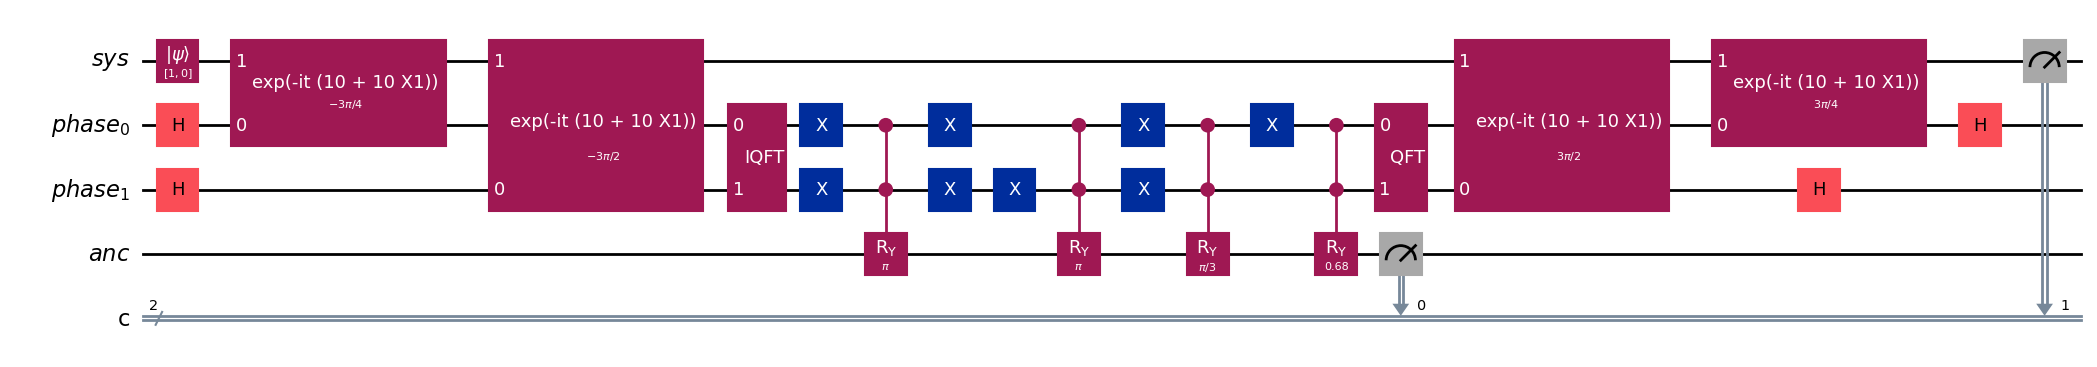

In [32]:
# Visualise the circuit
quantum_solver.build_circuit(A, b_vec).draw(
    output="mpl", filename="docs/beamer-slides/plots/circuit-mpl.jpeg", scale=1, fold=30)

/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


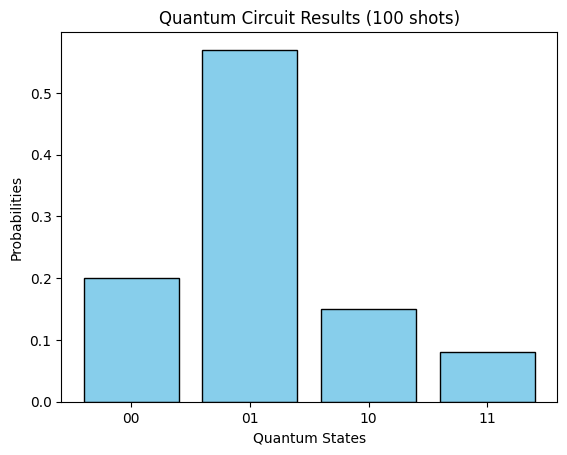

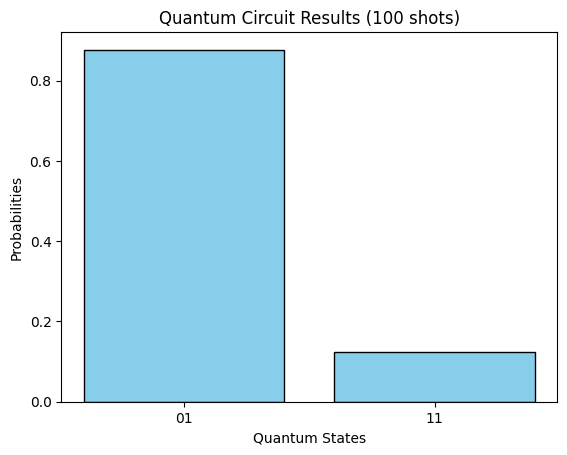

In [ ]:
# Raw counts
shots = 100
res_counts = quantum_solver.run_circuit(shots)
res_counts = dict(sorted(res_counts.items())) # Sorts keys to 00, 01, 10, 11

# Compute the probabilities
probabilities = {outcome: count / shots for outcome, count in sorted(res_counts.items())}
success_probs = {o: p for o, p in probabilities.items() if o.endswith("1")}
success_probs

plt.bar(probabilities.keys(), probabilities.values(), color='skyblue', edgecolor='black')
plt.xlabel('Quantum States')
plt.ylabel('Probabilities')
plt.title('Quantum Circuit Results (100 shots)')
plt.show()

# Conditional probabilities
p_anc1 = sum(success_probs.values())
p_anc1

conditional = {o: p / p_anc1 for o, p in success_probs.items()} if p_anc1 > 0 else {}
conditional

plt.bar(conditional.keys(), conditional.values(), color='skyblue', edgecolor='black')
plt.xlabel('Quantum States')
plt.ylabel('Probabilities')
plt.title('Quantum Circuit Results (100 shots)')
plt.show()